# 13-Statistical Canary Testing & Rollbacks

In Lesson 12, we engineered Shadow Deployments. We successfully routed cloned production traffic to our Challenger model, proving that it does not crash or leak memory under real-world load.

However, Shadow Deployments are invisible to the user. They cannot prove that the model actually drives better business outcomes, nor can they prove how real users will react to the new generative outputs. To definitively validate the model, we must expose it to real users.

If we switch 100% of our traffic from the Champion to the Challenger at once (a "Big Bang" deployment), a hidden logic flaw could instantly affect millions of users, triggering a catastrophic SLA breach. To engineer absolute safety, we execute a **Canary Release**. We route a tiny fraction of traffic (e.g., 5%) to the Challenger. We continuously compute the statistical divergence between the Champion and the Canary. If the Canary's performance degrades beyond a mathematical threshold, the infrastructure automatically severs the connection and rolls all traffic back to the Champion.

## 1. The Mathematics of Canary Analysis

A Canary deployment is fundamentally a continuous **A/B Hypothesis Test** executed on live infrastructure telemetry.

### The Null Hypothesis ($H_0$)

We monitor a specific Service Level Indicator (SLI), such as the Error Rate ($p$) or the Latency ($P_{99}$).
Let $A$ be the Champion (Baseline) and $B$ be the Canary (Challenger). Our Null Hypothesis assumes the Canary is performing equally to or better than the Champion.


$$H_0: p_B \le p_A$$

$$H_A: p_B > p_A$$

### The Proportions Z-Test

If we are monitoring the HTTP 500 Error Rate, we are dealing with binomial proportions. To determine if a spike in the Canary's error rate is statistically significant (and not just random noise from a small sample size), we calculate the Z-score.

Let $\hat{p}_A$ and $\hat{p}_B$ be the observed error rates, and $n_A$ and $n_B$ be the total number of requests routed to each model. The pooled error rate $\hat{p}$ is:


$$\hat{p} = \frac{x_A + x_B}{n_A + n_B}$$

We compute the test statistic $Z$:


$$Z = \frac{\hat{p}_B - \hat{p}_A}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_A} + \frac{1}{n_B}\right)}}$$

### The Automated Rollback Trigger

We define a strict confidence level $\alpha$ (typically $0.05$ or $0.01$). If the computed $Z$ exceeds the critical value $Z_{\alpha}$, we mathematically reject the Null Hypothesis. The infrastructure declares the Canary toxic and triggers an immediate, automated rollback to route $100\%$ of traffic back to the Champion.


## 2. Imperative Execution: The Statistical Rollback Engine

Let's build the mathematical engine that continuously monitors the telemetry from our API Gateway. We will simulate a traffic stream, calculate the Z-test in real-time, and trigger a simulated infrastructure rollback when the Canary becomes toxic.

In [1]:
# Required installations: pip install scipy numpy
import numpy as np
from scipy import stats
import time
import random

print("--- 🚀 Initializing Statistical Canary Sandbox ---")

# 1. 📝 Establish the Traffic Weights
TRAFFIC_SPLIT_CHAMPION = 0.95
TRAFFIC_SPLIT_CANARY = 0.05
ALPHA_THRESHOLD = 0.05 # 95% Confidence required to trigger a rollback

# State tracking
telemetry = {
    "champion": {"requests": 0, "errors": 0},
    "canary": {"requests": 0, "errors": 0}
}

def calculate_canary_z_test(tel: dict) -> float:
    nA = tel["champion"]["requests"]
    nB = tel["canary"]["requests"]
    
    if nA == 0 or nB == 0:
        return 1.0 # Cannot calculate p-value without data
        
    pA = tel["champion"]["errors"] / nA
    pB = tel["canary"]["errors"] / nB
    
    # Pooled proportion
    p_pool = (tel["champion"]["errors"] + tel["canary"]["errors"]) / (nA + nB)
    
    # Standard Error
    se = np.sqrt(p_pool * (1 - p_pool) * (1/nA + 1/nB))
    if se == 0:
        return 1.0
        
    # Z-statistic
    z = (pB - pA) / se
    
    # Calculate one-tailed p-value (We only care if Canary is WORSE)
    p_value = 1 - stats.norm.cdf(z)
    return p_value

print("\n--- 🧮 Executing Continuous Canary Monitoring ---")

# 2. ⚡ Simulate live production traffic
for minute in range(1, 11):
    # Simulate 10,000 requests per minute
    total_requests = 10000
    champ_reqs = int(total_requests * TRAFFIC_SPLIT_CHAMPION)
    canary_reqs = int(total_requests * TRAFFIC_SPLIT_CANARY)
    
    telemetry["champion"]["requests"] += champ_reqs
    telemetry["canary"]["requests"] += canary_reqs
    
    # Simulate normal Champion performance (1% error rate)
    telemetry["champion"]["errors"] += np.random.binomial(champ_reqs, 0.01)
    
    # Simulate a toxic Canary. At minute 5, it encounters an edge case and fails violently.
    true_canary_error_rate = 0.01 if minute < 5 else 0.04
    telemetry["canary"]["errors"] += np.random.binomial(canary_reqs, true_canary_error_rate)
    
    # 3. Mathematical Evaluation
    p_val = calculate_canary_z_test(telemetry)
    
    champ_err_rate = telemetry["champion"]["errors"] / telemetry["champion"]["requests"]
    canary_err_rate = telemetry["canary"]["errors"] / telemetry["canary"]["requests"]
    
    print(f"Minute {minute:02d} | Champ Err: {champ_err_rate*100:.2f}% | Canary Err: {canary_err_rate*100:.2f}% | p-value: {p_val:.4f}")
    
    # 4. The Rollback Gate
    if p_val < ALPHA_THRESHOLD:
        print("\n   🚨 CRITICAL ALERT: Canary error rate divergence is statistically significant (p < 0.05).")
        print("   ❌ AUTOMATED ACTION: Severing Canary routing. Rolling 100% of traffic back to Champion.")
        break
    
    time.sleep(0.1) # Accelerated simulation

--- 🚀 Initializing Statistical Canary Sandbox ---

--- 🧮 Executing Continuous Canary Monitoring ---
Minute 01 | Champ Err: 0.94% | Canary Err: 0.80% | p-value: 0.6220
Minute 02 | Champ Err: 1.02% | Canary Err: 0.80% | p-value: 0.7476
Minute 03 | Champ Err: 0.95% | Canary Err: 0.93% | p-value: 0.5326
Minute 04 | Champ Err: 0.99% | Canary Err: 0.90% | p-value: 0.6494
Minute 05 | Champ Err: 1.02% | Canary Err: 1.48% | p-value: 0.0135

   🚨 CRITICAL ALERT: Canary error rate divergence is statistically significant (p < 0.05).
   ❌ AUTOMATED ACTION: Severing Canary routing. Rolling 100% of traffic back to Champion.


## 3. Declarative Execution: Infrastructure Traffic Splitting (NGINX)

Handling traffic splitting inside Python is an anti-pattern; it requires changing application code to route networks. In Enterprise MLOps, we delegate this to the proxy layer.

We use the NGINX `split_clients` module. This module hashes the incoming user's IP address to ensure **Session Stickiness** (the same user is consistently routed to the same model during the test, preventing a schizophrenic UX).

In [2]:
import os

print("\n--- ⚡ Compiling Declarative Canary Routing (NGINX) ---")

canary_sandbox = "./canary_sandbox"
os.makedirs(canary_sandbox, exist_ok=True)

# 📝 Compile the NGINX Canary Configuration
nginx_canary_conf = """
events {}

http {
    upstream champion_cluster { server host.docker.internal:8000; }
    upstream canary_cluster { server host.docker.internal:8001; }

    # 1. The Statistical Hashing Engine
    # Hashes the client's IP address into a 32-bit integer, guaranteeing stickiness.
    split_clients "${remote_addr}" $ml_variant {
        5%      canary_cluster;
        *       champion_cluster;
    }

    server {
        listen 80;

        location /predict {
            # 2. The Dynamic Proxy Route
            # NGINX automatically resolves $ml_variant to the correct cluster based on the hash
            proxy_pass http://$ml_variant;
            
            # Inject tracking headers for Prometheus metrology
            proxy_set_header X-Model-Variant $ml_variant;
        }
    }
}
"""

conf_path = os.path.join(canary_sandbox, "nginx_canary.conf")
with open(conf_path, "w") as f:
    f.write(nginx_canary_conf.strip())

print(f"   ✅ NGINX Canary Configuration Compiled: {conf_path}")
print("   -> Physics: When the Rollback Engine detects toxicity, a CI/CD pipeline instantly rewrites this file to remove the 5% split and reloads the NGINX daemon, terminating the Canary in milliseconds.")


--- ⚡ Compiling Declarative Canary Routing (NGINX) ---
   ✅ NGINX Canary Configuration Compiled: ./canary_sandbox/nginx_canary.conf
   -> Physics: When the Rollback Engine detects toxicity, a CI/CD pipeline instantly rewrites this file to remove the 5% split and reloads the NGINX daemon, terminating the Canary in milliseconds.


## 4. Visualizing Canary Divergence (The Rollback Trigger)

To mathematically comprehend why we rely on statistical significance rather than raw thresholds, let's visualize the error rate trajectory and the widening confidence interval that triggers the rollback.

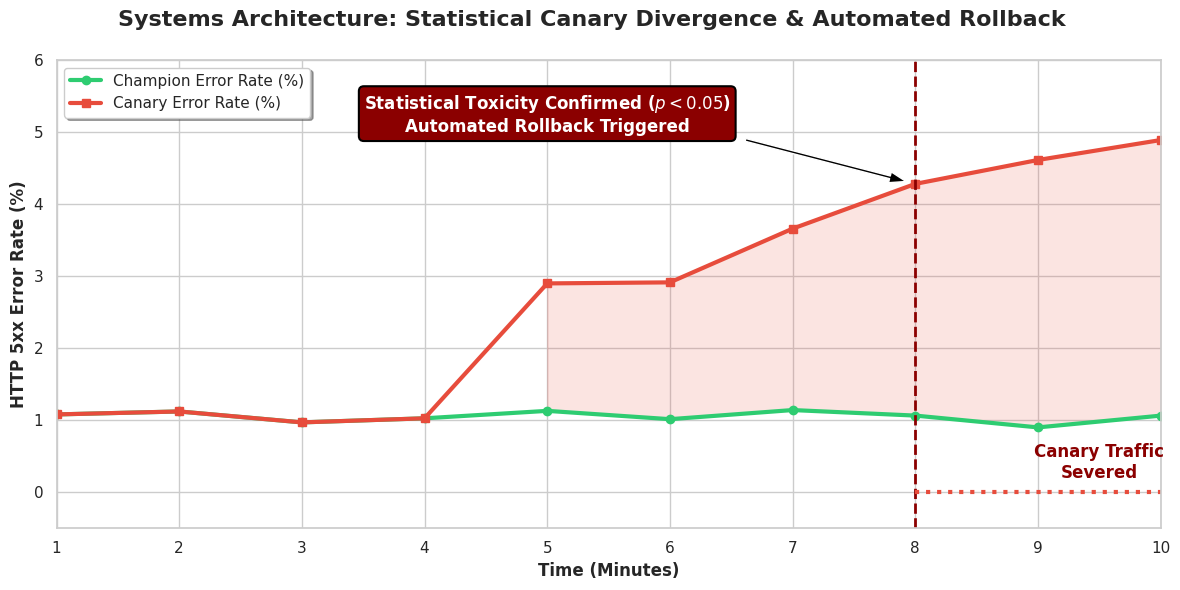

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for Canary Rollback Physics
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: Statistical Canary Divergence & Automated Rollback", fontsize=16, fontweight='bold')

# Simulate Time Series Data (10 minutes)
time_mins = np.arange(1, 11, 1)

# Champion maintains a steady 1% error rate with minor noise
champ_err = np.random.normal(1.0, 0.1, size=10)

# Canary tracks the Champion perfectly until Minute 5, then spikes severely
canary_err = np.copy(champ_err)
canary_err[4:] += np.linspace(1.5, 4.0, 6) + np.random.normal(0, 0.2, size=6)

ax.plot(time_mins, champ_err, color='#2ecc71', linewidth=3, marker='o', label='Champion Error Rate (%)')
ax.plot(time_mins, canary_err, color='#e74c3c', linewidth=3, marker='s', label='Canary Error Rate (%)')

# Highlight the Statistical Divergence Zone
ax.fill_between(time_mins[4:], champ_err[4:], canary_err[4:], color='#e74c3c', alpha=0.15)

# The Rollback Event (Minute 8, when p-value drops below 0.05)
rollback_min = 8
ax.axvline(x=rollback_min, color='darkred', linestyle='--', linewidth=2)

ax.annotate('Statistical Toxicity Confirmed ($p < 0.05$)\nAutomated Rollback Triggered', 
            xy=(rollback_min, canary_err[rollback_min-1]), xytext=(rollback_min - 3, 5.0),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', fontweight='bold', color='white',
            bbox=dict(boxstyle="round,pad=0.3", fc="darkred", ec="black", lw=1.5))

# Post-Rollback Canary Traffic drops to Zero
ax.plot(time_mins[rollback_min-1:], np.zeros(len(time_mins[rollback_min-1:])), color='#e74c3c', linestyle=':', linewidth=3)
ax.text(9.5, 0.2, "Canary Traffic\nSevered", ha='center', color='darkred', fontweight='bold')

ax.set_xlabel("Time (Minutes)", fontsize=12, fontweight='bold')
ax.set_ylabel("HTTP 5xx Error Rate (%)", fontsize=12, fontweight='bold')
ax.set_xlim(1, 10)
ax.set_ylim(-0.5, 6.0)
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

*(Insight: At Minute 5, the Canary error rate rises, but the sample size is too small to definitively prove it isn't random noise. By Minute 8, the mathematical evidence ($p$-value) breaches the rigid $0.05$ threshold. The system does not wait for human intervention; it physically drops the Canary routing to $0\%$, isolating the damage to a maximum of $5\%$ of users over a strict $3\text{-minute}$ window.)*

## Real-World Use Case or Analogy

Think of Canary Testing like **Testing a New Water Purification Chemical for a City**:

* **Shadow Testing (Lesson 12 - The Laboratory):** You take a sample of the city's water into an isolated lab. You apply the new chemical (The Challenger). You test the water. It works perfectly. But a lab is not a real city with miles of rusted pipes and unpredictable temperatures.
* **The Big Bang Deployment (The Catastrophe):** You dump the new chemical into the city's main reservoir, switching 100% of the water supply immediately. You later discover the chemical reacts violently with the lead pipes in one specific neighborhood. The entire city is poisoned.
* **Canary Deployment (The Safe Rollout):** You isolate a single, small neighborhood (5% of the city). You route the new chemically treated water exclusively to their pipes.
* You install high-speed sensors (Prometheus) on their taps, strictly comparing their water quality against the rest of the city (The Champion).
* If the sensors detect a statistically significant spike in heavy metals in that specific neighborhood (**$p$-value $< 0.05$**), an automated mechanical valve (**NGINX**) slams shut, instantly routing the clean baseline water back to that neighborhood.
* You contained a fatal architectural flaw to a tiny, mathematically bounded radius, allowing your engineering team to investigate the failure safely.